# Paso 3 — Diseño experimental y resultados
**Pregunta:** ¿puede un modelo de ensamble predecir si un canal de la red DWDM ferroviaria Moscú-Kazánskaya – Riazán cumple BER ≤ 10⁻¹¹ mejor que un modelo lineal sencillo?

Este cuaderno se ejecuta de arriba abajo con ▶ (o *Run All*). Usa dos archivos de esta carpeta:
- `simulador.py`: el modelo físico que genera los datos sintéticos.
- `experimento.py`: entrena los modelos, calcula la tabla y dibuja las figuras.

## 1. Comprobar el modelo físico con el caso del TFG
El tramo más desfavorable del proyecto (Voskresensk – Riazán-1, 108,9 km) debe cumplir cuando la red es nueva.

In [1]:
import numpy as np
import simulador as sim

d = np.array([108.9])
perdida = sim.perdida_nominal(d)[0]
print(f"Pérdida nominal: {perdida:.1f} dB -> potencia en el preamplificador: {-perdida:.1f} dBm")
q = sim.q_ase(58 - perdida - 6.5)          # figura de ruido del EDFA: 6,5 dB
print(f"Q = {q:.2f}  ->  BER = {sim.ber_desde_q(q):.1e}  (el TFG obtuvo Q = 7,37)")

Pérdida nominal: 32.8 dB -> potencia en el preamplificador: -32.8 dBm
Q = 10.54  ->  BER = 2.8e-26  (el TFG obtuvo Q = 7,37)


## 2. Generar el conjunto de datos
10 000 canales entre pares de estaciones reales de la línea, con entre 0 y 25 años de servicio, reparaciones, hielo y envejecimiento.
Las columnas `oculta_*` son causas físicas que **el operador no puede medir**: no se dan a los modelos en los escenarios A y B.

In [2]:
df = sim.generar(n=10000, semilla=42)
print("Proporción de canales que NO cumplen:", round(1 - df.cumple.mean(), 3))
df.head()

Proporción de canales que NO cumplen: 0.204


,longitud_km,amplificado,n_vanos,antiguedad_anios,reparaciones_registradas,temperatura_c,p_rx_medida_dbm,oculta_perdida_reparaciones_db,oculta_perdida_hielo_db,oculta_perdida_conectores_db,oculta_nf_db,oculta_alfa_db_km,q,ber,cumple
0,192.4,1,2,5.45,4,-7.4,-29.83,5.350,0.0,1.047,6.62,0.2244,9.144,3.009186e-20,1
1,78.5,1,1,16.57,8,-23.3,-35.95,8.673,0.0,1.850,7.30,0.2310,6.268,1.830848e-10,0
2,63.5,0,1,19.17,9,-10.4,-32.41,8.771,0.0,1.017,7.26,0.2332,1.051,1.465176e-01,0
3,14.9,0,1,4.17,1,22.4,-11.83,0.372,0.0,1.126,6.79,0.2260,165.545,0.000000e+00,1
4,10.3,0,1,1.10,0,2.1,-9.61,0.000,0.0,1.580,6.19,0.2210,231.859,0.000000e+00,1


In [3]:
df.describe().T[["mean", "min", "max"]]

,mean,min,max
longitud_km,73.507170,5.400,198.300000
amplificado,0.502800,0.000,1.000000
n_vanos,1.233000,1.000,2.000000
antiguedad_anios,12.503051,0.000,25.000000
reparaciones_registradas,4.722000,0.000,44.000000
temperatura_c,2.645460,-30.000,35.000000
p_rx_medida_dbm,-24.423400,-58.090,-5.640000
oculta_perdida_reparaciones_db,4.335134,0.000,37.573000
oculta_perdida_hielo_db,0.326210,0.000,4.988000
oculta_perdida_conectores_db,1.400202,1.000,4.524000


## 3. Entrenar, validar y dibujar
`experimento.py` compara regresión logística, Random Forest y XGBoost en tres escenarios:
- **A: planificación**: solo datos del inventario (longitud, amplificación, antigüedad, reparaciones registradas, temperatura).
- **B: monitorización**: lo anterior más la potencia recibida que mide el propio transceptor.
- **C: oráculo**: además, las causas ocultas (solo como referencia: en la realidad no se conocen).

Validación cruzada estratificada de 10 pliegues repetida 3 veces, y prueba de McNemar en un conjunto de prueba del 30 %. Tarda unos 2–3 minutos.

In [4]:
%run experimento.py

Canales: 10000 | no cumplen: 20.4%


A: planificación | Regresión logística | AUC 0.983 ± 0.003 | F1 0.832 ± 0.014


A: planificación | Random Forest | AUC 0.981 ± 0.003 | F1 0.847 ± 0.015


A: planificación | XGBoost | AUC 0.982 ± 0.003 | F1 0.845 ± 0.014


B: monitorización | Regresión logística | AUC 0.998 ± 0.001 | F1 0.931 ± 0.009


...

C: oráculo (con variables ocultas) | Regresión logística | AUC 0.998 ± 0.001 | F1 0.940 ± 0.010


C: oráculo (con variables ocultas) | Random Forest | AUC 0.998 ± 0.001 | F1 0.951 ± 0.011


C: oráculo (con variables ocultas) | XGBoost | AUC 0.999 ± 0.001 | F1 0.958 ± 0.011


Random Forest vs Regresión logística (escenario B, test 30 %): solo acierta Random Forest: 44; solo acierta la logística: 13; chi2 = 15.79; p = 7.08e-05
XGBoost vs Regresión logística (escenario B, test 30 %): solo acierta XGBoost: 54; solo acierta la logística: 23; chi2 = 11.69; p = 6.29e-04


Listo: datos/, resultados/ y figuras/ generados.


## 4. Resultados

In [5]:
import pandas as pd
tabla = pd.read_csv("resultados/tabla_resultados.csv")
tabla[["Escenario", "Modelo", "AUC", "Exactitud equilibrada", "Sensibilidad (no cumple)", "F1 (no cumple)"]]

,Escenario,Modelo,AUC,Exactitud equilibrada,Sensibilidad (no cumple),F1 (no cumple)
0,A: planificación,Regresión logística,0.983 ± 0.003,0.929 ± 0.009,0.939 ± 0.017,0.832 ± 0.014
1,A: planificación,Random Forest,0.981 ± 0.003,0.921 ± 0.011,0.901 ± 0.023,0.847 ± 0.015
2,A: planificación,XGBoost,0.982 ± 0.003,0.925 ± 0.010,0.914 ± 0.019,0.845 ± 0.014
3,B: monitorización,Regresión logística,0.998 ± 0.001,0.977 ± 0.004,0.987 ± 0.007,0.931 ± 0.009
4,B: monitorización,Random Forest,0.998 ± 0.001,0.976 ± 0.007,0.974 ± 0.012,0.947 ± 0.012
5,B: monitorización,XGBoost,0.998 ± 0.001,0.973 ± 0.008,0.964 ± 0.014,0.947 ± 0.012
6,C: oráculo (con variables ocultas),Regresión logística,0.998 ± 0.001,0.980 ± 0.004,0.991 ± 0.006,0.940 ± 0.010
7,C: oráculo (con variables ocultas),Random Forest,0.998 ± 0.001,0.978 ± 0.006,0.976 ± 0.011,0.951 ± 0.011
8,C: oráculo (con variables ocultas),XGBoost,0.999 ± 0.001,0.978 ± 0.007,0.969 ± 0.012,0.958 ± 0.011


In [6]:
print(open("resultados/mcnemar.txt", encoding="utf-8").read())

Random Forest vs Regresión logística (escenario B, test 30 %): solo acierta Random Forest: 44; solo acierta la logística: 13; chi2 = 15.79; p = 7.08e-05
XGBoost vs Regresión logística (escenario B, test 30 %): solo acierta XGBoost: 54; solo acierta la logística: 23; chi2 = 11.69; p = 6.29e-04



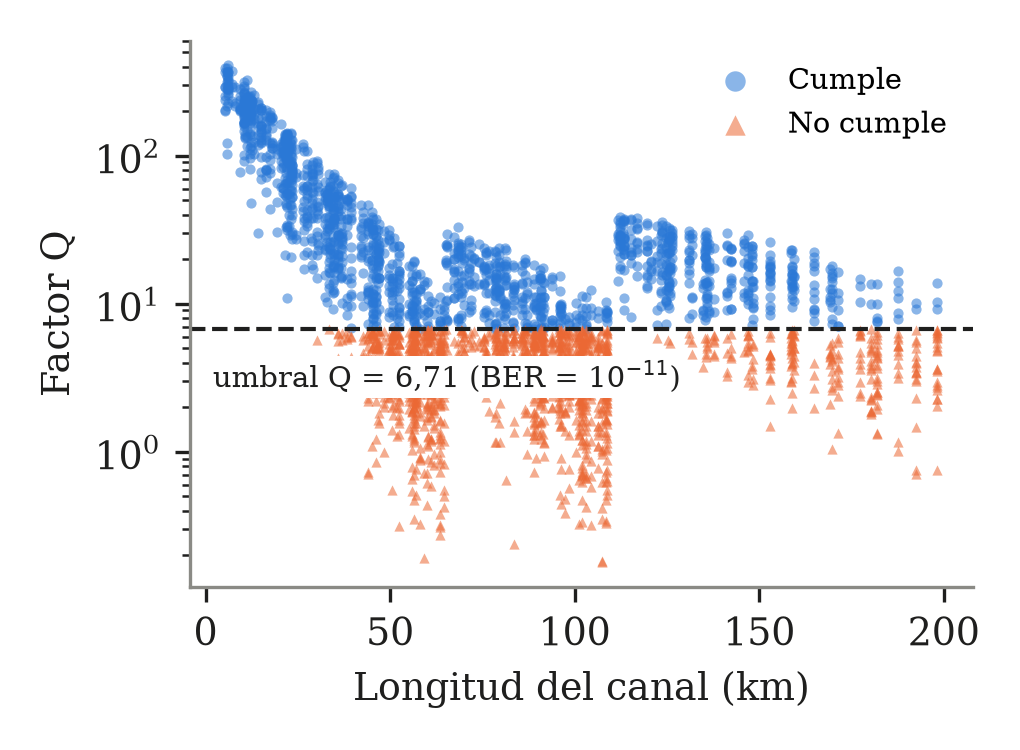

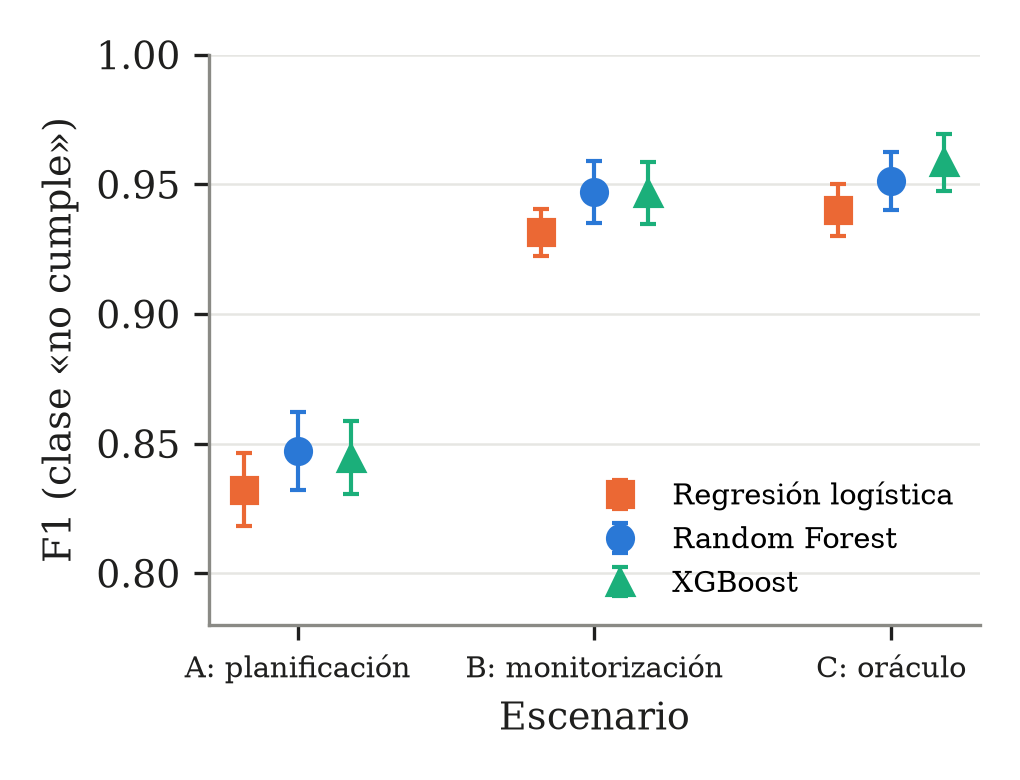

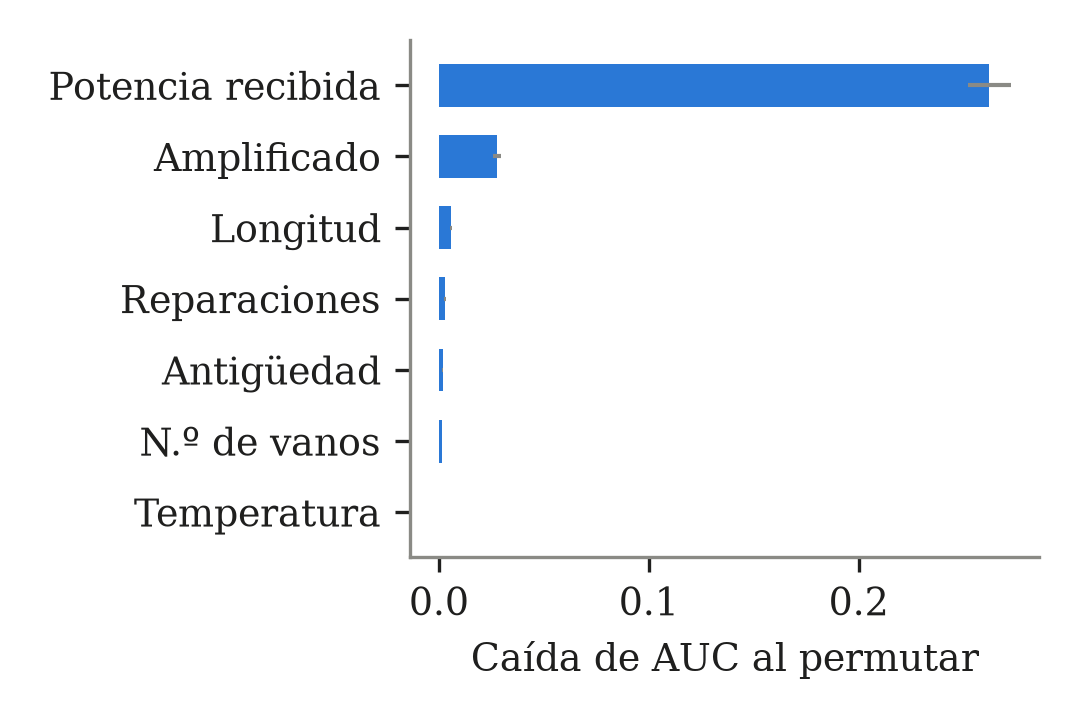

In [7]:
from IPython.display import Image, display
for f in ["fig1_q_vs_longitud", "fig2_f1_escenarios", "fig3_importancia"]:
    display(Image(f"figuras/{f}.png", width=450))